# Process Mining Milestone 1 - Polluter Script

Group C

In [3]:
import pandas as pd
import pm4py

In [4]:
log = pm4py.read_xes("../data/BPI Challenge 2017.xes.gz")
df = pm4py.convert_to_dataframe(log)

/Users/felixhauptmann/ProM-Assignment-Group-C/.venv/lib/python3.13/site-packages/pm4py/utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

## Pollution Script

### 1. Unanchored Events

In [8]:
print(df["EventOrigin"].unique())
print(df.columns.tolist())

<StringArray>
['Application', 'Workflow', 'Offer']
Length: 3, dtype: str
['Action', 'org:resource', 'concept:name', 'EventOrigin', 'EventID', 'lifecycle:transition', 'time:timestamp', 'case:LoanGoal', 'case:ApplicationType', 'case:concept:name', 'case:RequestedAmount', 'FirstWithdrawalAmount', 'NumberOfTerms', 'Accepted', 'MonthlyCost', 'Selected', 'CreditScore', 'OfferedAmount', 'OfferID']


In [9]:
df_unanchored = df.copy()

# simulate different data sources (for unique values of EventOrigin)
mask_app = df_unanchored["EventOrigin"] == "Application"
mask_offer = df_unanchored["EventOrigin"] == "Offer"

# convert timestamp objects into strings
df_unanchored["time:timestamp"] = df_unanchored["time:timestamp"].astype("string")

# change the format of timestamp for all rows of a simulated data source
    # format: dd.mm.YYYY HH:MM:SS
df_unanchored.loc[mask_app, "time:timestamp"] = (
    pd.to_datetime(df_unanchored.loc[mask_app, "time:timestamp"], errors="coerce")
    .dt.strftime("%d.%m.%Y %H:%M:%S")
)

# format: YYYY-mm-dd'T'HH:MM:SS:MS'Z'
df_unanchored.loc[mask_offer, "time:timestamp"] = (
    pd.to_datetime(df_unanchored.loc[mask_offer, "time:timestamp"], errors="coerce")
    .dt.strftime("%Y-%m-%dT%H:%M:%S.%fZ")
)

In [10]:
# output to show heterogenous timestamp formats of different simulated data sources (EventOrigin)
for origin in ["Application", "Workflow", "Offer"]:
    print("\n", origin)
    print(
        df_unanchored[df_unanchored["EventOrigin"] == origin]
        .sort_values("time:timestamp")
        .head(5)[["EventOrigin", "time:timestamp"]]
    )


 Application
    EventOrigin       time:timestamp
0   Application  01.01.2016 09:51:15
1   Application  01.01.2016 09:51:15
5   Application  01.01.2016 09:52:36
41  Application  01.01.2016 10:16:11
40  Application  01.01.2016 10:16:11

 Workflow
   EventOrigin                    time:timestamp
2     Workflow  2016-01-01 09:51:15.774000+00:00
3     Workflow  2016-01-01 09:52:36.392000+00:00
4     Workflow  2016-01-01 09:52:36.403000+00:00
42    Workflow  2016-01-01 10:16:11.740000+00:00
43    Workflow  2016-01-01 10:17:31.573000+00:00

 Offer
    EventOrigin               time:timestamp
917       Offer  2016-01-02T09:17:05.720000Z
918       Offer  2016-01-02T09:17:08.762000Z
919       Offer  2016-01-02T09:19:21.330000Z
924       Offer  2016-01-02T09:21:26.034000Z
925       Offer  2016-01-02T09:21:42.022000Z


In [11]:
#check how many events per time format
s = df_unanchored["time:timestamp"].astype(str).str.strip()

iso_mask = s.str.match(r"^\d{4}-\d{2}-\d{2}", na=False)
eu_mask = s.str.match(r"^\d{1,2}\.\d{1,2}\.\d{4}", na=False)
us_mask = s.str.match(r"^\d{1,2}/\d{1,2}/\d{4}", na=False)
utc_mask = s.str.match(r"^\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d+Z$", na=False)

print("ISO:", iso_mask.sum())
print("European:", eu_mask.sum())
print("US-like:", us_mask.sum())
print("UTC:", utc_mask.sum())
print("unknown:", (~(iso_mask | eu_mask | us_mask)).sum())

ISO: 962480
European: 239373
US-like: 0
UTC: 193657
unknown: 414


In [12]:
df_unanchored.to_csv("../data/unanchored_events.csv.gz", index=False, sep=";", compression="gzip")

### 2. Polluted Labels

In [13]:
import random
import numpy as np

In [14]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [15]:
def pollute_labels(df, rate = 0.001):
    df = df.copy()
    n = int(len(df) * rate)
    indices = np.random.choice(df.index, n, replace=False)

    for index in indices:
        activity = df.loc[index, "concept:name"]
        case_id = df.loc[index, "case:concept:name"]
        df.loc[index, "concept:name"] = f"{activity} - Incident No. {case_id}"

    return df

In [16]:
df_polluted = df.copy()
df_polluted = pollute_labels(df_polluted)

In [17]:
print(f"unique cases df: {df["concept:name"].nunique()}")
print(f"unique cases polluted: {df_polluted["concept:name"].nunique()}")

unique cases df: 26
unique cases polluted: 1222


In [18]:
df_polluted["concept:name"].unique().tolist()

['A_Create Application',
 'A_Submitted',
 'W_Handle leads',
 'W_Complete application',
 'A_Concept',
 'A_Accepted',
 'O_Create Offer',
 'O_Created',
 'O_Sent (mail and online)',
 'W_Call after offers',
 'A_Complete',
 'W_Validate application',
 'A_Validating',
 'O_Returned',
 'W_Call incomplete files',
 'A_Incomplete',
 'W_Call incomplete files - Incident No. Application_652823628',
 'O_Accepted',
 'A_Pending',
 'A_Denied',
 'O_Refused',
 'O_Cancelled',
 'A_Cancelled',
 'O_Sent (online only)',
 'W_Call incomplete files - Incident No. Application_821425679',
 'W_Handle leads - Incident No. Application_1461440233',
 'W_Validate application - Incident No. Application_486645986',
 'W_Call after offers - Incident No. Application_909491524',
 'A_Validating - Incident No. Application_1101248362',
 'W_Call incomplete files - Incident No. Application_1868808301',
 'O_Sent (mail and online) - Incident No. Application_866541745',
 'A_Validating - Incident No. Application_190984886',
 'O_Accepted 

### 3. Distorted Labels

In [19]:
df["concept:name"].unique()

<StringArray>
[      'A_Create Application',                'A_Submitted',
             'W_Handle leads',     'W_Complete application',
                  'A_Concept',                 'A_Accepted',
             'O_Create Offer',                  'O_Created',
   'O_Sent (mail and online)',        'W_Call after offers',
                 'A_Complete',     'W_Validate application',
               'A_Validating',                 'O_Returned',
    'W_Call incomplete files',               'A_Incomplete',
                 'O_Accepted',                  'A_Pending',
                   'A_Denied',                  'O_Refused',
                'O_Cancelled',                'A_Cancelled',
       'O_Sent (online only)',   'W_Assess potential fraud',
 'W_Personal Loan collection',    'W_Shortened completion ']
Length: 26, dtype: str

In [20]:
def distort_activity_label(label):
    replacements = {
        "application": "appl.",
        "Application": "App.",
        "offers": "ofrs.",
        "Offer": "Off.",
        "incomplete": "incompl.",
        "Incomplete": "Incompl.",
        "files": "docs.",
        "leads": "lds.",
        "Handle": "Hndl.",
        "Validate": "Valid.",
        "Validating": "Valid.",
        "Complete": "Comp.",
        "Created": "Crtd.",
        "Create": "Crt.",
        "Accepted": "Acc.",
        "Cancelled": "Canc.",
        "Submitted": "Subm.",
        "Pending": "Pend.",
        "Denied": "Den.",
        "Refused": "Ref.",
        "Returned": "Ret.",
        "potential": "pot.",
        "fraud": "frd.",
        "Shortened": "Short.",
        "completion": "compl.",
        "Personal": "Pers.",
        "Loan": "Ln.",
        "collection": "coll.",
        "online": "onl.",
        "mail": "email"
    }

    distorted = str(label)

    for original, replacement in replacements.items():
        if original in distorted:
            return distorted.replace(original, replacement, 1)

    return distorted + "."

In [21]:
def pollute_distorted_labels(
    df,
    activity_column="concept:name",
    rate=0.05,
    pollution_column="pollution_type"
):
    df = df.copy()

    if pollution_column not in df.columns:
        df[pollution_column] = None

    n = int(len(df) * rate)
    indices = np.random.choice(df.index, n, replace=False)

    for index in indices:
        original_label = df.loc[index, activity_column]

        if pd.notna(original_label):
            distorted_label = distort_activity_label(original_label)

            df.loc[index, activity_column] = distorted_label
            df.loc[index, pollution_column] = "distorted_label"

    return df

In [22]:
df_polluted = pollute_distorted_labels(
    df_polluted,
    activity_column="concept:name",
    rate=0.05
)

In [23]:
print("Original unique activities:", df["concept:name"].nunique())
print("Polluted unique activities:", df_polluted["concept:name"].nunique())

df_polluted["pollution_type"].value_counts()

Original unique activities: 26
Polluted unique activities: 1248


pollution_type
distorted_label    60113
Name: count, dtype: int64

In [24]:
df_polluted["concept:name"].unique().tolist()

['A_Create Application',
 'A_Subm.',
 'W_Handle leads',
 'W_Complete application',
 'A_Concept',
 'A_Accepted',
 'O_Create Off.',
 'O_Created',
 'O_Sent (mail and online)',
 'W_Call after offers',
 'A_Complete',
 'W_Validate application',
 'A_Validating',
 'O_Returned',
 'W_Call incomplete files',
 'A_Incompl.',
 'W_Call incomplete files - Incident No. Application_652823628',
 'W_Validate appl.',
 'O_Accepted',
 'A_Pending',
 'A_Submitted',
 'O_Create Offer',
 'W_Call after ofrs.',
 'A_Denied',
 'O_Refused',
 'O_Cancelled',
 'W_Complete appl.',
 'A_Incomplete',
 'A_Valid.',
 'W_Call incompl. files',
 'A_Canc.',
 'A_Create App.',
 'A_Cancelled',
 'A_Acc.',
 'O_Ret.',
 'W_Handle lds.',
 'A_Pend.',
 'O_Sent (mail and onl.)',
 'O_Sent (online only)',
 'O_Crtd.',
 'A_Concept.',
 'A_Comp.',
 'O_Sent (onl. only)',
 'O_Canc.',
 'W_Call incomplete files - Incident No. Application_821425679',
 'W_Handle leads - Incident No. Application_1461440233',
 'W_Validate application - Incident No. Applica

### 4. Synonymous Labels

In [25]:
SYNONYMS = {
    "W_Complete application": ["W_Finish application", "W_Submit application", "W_Finalize application"],
    "W_Call incomplete files": ["W_Follow up files", "W_Chase incomplete files"]
}

In [26]:
def add_synonymous_labels(df: pd.DataFrame, fraction: float = 0.3) -> pd.DataFrame:
    """Add synonymous labels randomly to a fraction of the occurrences of specified activities"""
    df = df.copy()
    for original, alternatives in SYNONYMS.items():
        original_rows = df[df["concept:name"] == original]

        if original_rows.empty:
            print(f"[synonymous_labels] Warning: '{original}' not found in log, skipping.")
            continue

        sampled_idx = original_rows.sample(frac=fraction).index
        mask = (df["concept:name"] == original) & (df.index.isin(sampled_idx))
        df.loc[mask, "concept:name"] = [random.choice(alternatives) for _ in range(mask.sum())]

        print(f"[synonymous_labels] Replaced {mask.sum()} / {len(original_rows)} "
              f"occurrences of '{original}'")

    return df

In [27]:
# Most common activities
df["concept:name"].value_counts().head(10)

concept:name
W_Validate application      209496
W_Call after offers         191092
W_Call incomplete files     168529
W_Complete application      148900
W_Handle leads               47264
O_Create Offer               42995
O_Created                    42995
O_Sent (mail and online)     39707
A_Validating                 38816
A_Create Application         31509
Name: count, dtype: int64

In [28]:
polluted_df_1 = add_synonymous_labels(df)
polluted_df_1["concept:name"].value_counts().head(20)

[synonymous_labels] Replaced 44670 / 148900 occurrences of 'W_Complete application'
[synonymous_labels] Replaced 50559 / 168529 occurrences of 'W_Call incomplete files'


concept:name
W_Validate application      209496
W_Call after offers         191092
W_Call incomplete files     117970
W_Complete application      104230
W_Handle leads               47264
O_Create Offer               42995
O_Created                    42995
O_Sent (mail and online)     39707
A_Validating                 38816
A_Create Application         31509
A_Concept                    31509
A_Accepted                   31509
A_Complete                   31362
W_Chase incomplete files     25288
W_Follow up files            25271
O_Returned                   23305
A_Incomplete                 23055
O_Cancelled                  20898
A_Submitted                  20423
O_Accepted                   17228
Name: count, dtype: int64

### 5. Collateral Events

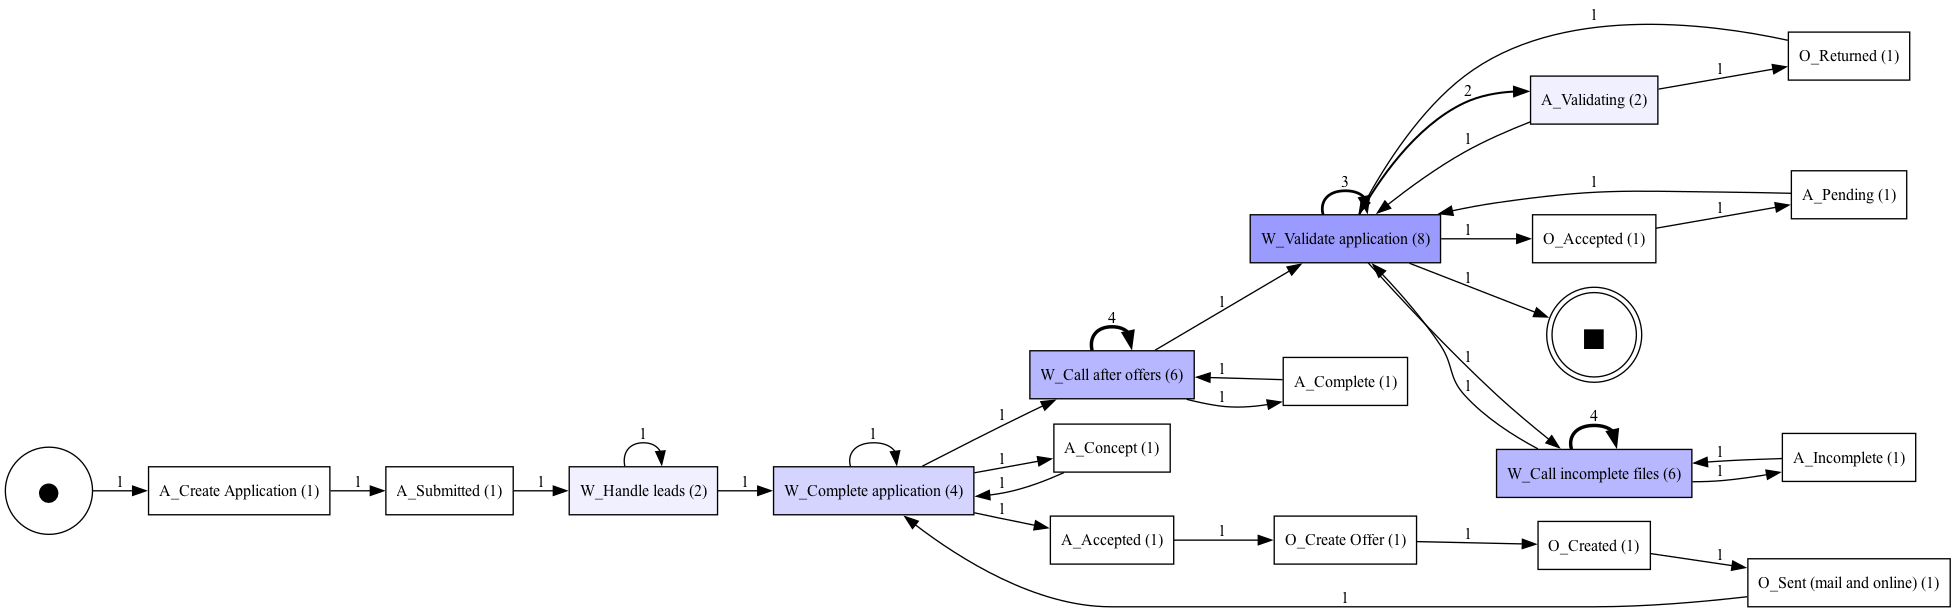

In [29]:
case_list = list(df['case:concept:name'].unique())
dfg, start_activities, end_activities = pm4py.discover_dfg(df[df['case:concept:name'].isin(case_list[:1])])
pm4py.view_dfg(dfg, start_activities, end_activities)

In [30]:
df[df['concept:name']=='W_Complete application'][['Action', 'concept:name', 'lifecycle:transition']].drop_duplicates()

,Action,concept:name,lifecycle:transition
4,Created,W_Complete application,schedule
6,Obtained,W_Complete application,start
7,Released,W_Complete application,suspend
12,Deleted,W_Complete application,ate_abort
48,Obtained,W_Complete application,resume
53,Deleted,W_Complete application,complete
461,Deleted,W_Complete application,withdraw


In [31]:
df['Action'].value_counts()

Action
statechange    358940
Obtained       255387
Created        223608
Released       215402
Deleted        148930
Name: count, dtype: int64

In [32]:
df['lifecycle:transition'].value_counts()

lifecycle:transition
complete     475306
suspend      215402
schedule     149104
start        128227
resume       127160
ate_abort     85224
withdraw      21844
Name: count, dtype: int64

In [33]:
# Sub-steps that logically make up "W_Complete application" - Action = Obtained, lifecycle:transition = start
COLLATERAL_SUBSTEPS = [
    "W_Precheck application: Applicant Identity",
    "W_Precheck application: Form Completeness",
    "W_Precheck application: Credit History",
]

In [34]:
def add_collateral_events(
    df: pd.DataFrame,
    concept_name: str = "W_Complete application",
    action: str = "Obtained",
    lifecycle_transition: str = "start",
    fraction: float = 0.001
) -> pd.DataFrame:
    """
    Inject collateral sub-steps for a fraction of cases.
    Each injected sub-step inherits all column values from the anchor event
    except 'concept:name', 'time:timestamp', and 'start_timestamp', which
    are updated to reflect the sub-step identity and timing (1 second apart)

    Args:
        df (pd.DataFrame): Event log dataframe
        concept_name (str): Activity name to use as the injection anchor
        action (str): The 'Action' column value of the anchor event
        lifecycle_transition (str): The 'lifecycle:transition' value of the anchor event
        fraction (float): Fraction of eligible cases to inject sub-steps into

    Returns:
        pd.DataFrame: Copy of the dataframe with injected collateral sub-step rows
    """
    df = df.copy()
    new_rows = []

    # Get cases that contain W_Complete application with Obtained/start
    target_cases = df[
        (df["concept:name"] == concept_name) &
        (df["Action"] == action) &
        (df["lifecycle:transition"] == lifecycle_transition)
    ]["case:concept:name"].unique()

    if len(target_cases) == 0:
        print(f"[collateral_events] Warning: No matching anchor events found, returning unchanged df.")
        return df
    n_sampled = max(1, int(len(target_cases) * fraction))
    sampled_cases = random.sample(list(target_cases), n_sampled)

    for case_id in sampled_cases:
        # Find specifically the Obtained/start event
        anchor = df[
            (df["case:concept:name"] == case_id) &
            (df["concept:name"] == concept_name) &
            (df["Action"] == action) &
            (df["lifecycle:transition"] == lifecycle_transition)
        ].iloc[0]

        anchor_time = anchor["time:timestamp"]

        # Inject sub-steps after the start event, 1 second apart
        for i, substep in enumerate(COLLATERAL_SUBSTEPS):
            new_rows.append({
                **anchor.to_dict(),
                "concept:name": substep,
                "time:timestamp": anchor_time + pd.Timedelta(seconds=i + 1),
                "start_timestamp": anchor_time + pd.Timedelta(seconds=i + 1),
            })

    new_df = pd.DataFrame(new_rows)
    return pd.concat([df, new_df]).sort_values(
        ["case:concept:name", "time:timestamp"]
    ).reset_index(drop=True)

In [35]:
polluted_df_2 = add_collateral_events(df)

In [36]:
target_cases = polluted_df_2[polluted_df_2["concept:name"] == "W_Precheck application: Applicant Identity"]["case:concept:name"].unique()
target_cases

<StringArray>
['Application_1103246808', 'Application_1366758339', 'Application_1369290283',
 'Application_1381149703', 'Application_1548078856', 'Application_1614763685',
 'Application_1617021214', 'Application_1712536446',  'Application_174818263',
 'Application_1786512599', 'Application_2031600035', 'Application_2048411605',
 'Application_2113251818', 'Application_2120756983',  'Application_225586063',
  'Application_285199122',  'Application_338533270',  'Application_349515920',
  'Application_522494401',  'Application_525287846',  'Application_549538953',
  'Application_592572289',  'Application_607309528',  'Application_686689435',
  'Application_822422484',   'Application_83055924',  'Application_944126106',
  'Application_972369663',   'Application_99213678']
Length: 29, dtype: str

In [37]:
test_raw = df[df["case:concept:name"]=='Application_1005851562'].sort_values(by=["case:concept:name", "time:timestamp"])
test_raw

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID
316557,Created,User_1,A_Create Application,Application,Application_1005851562,complete,2016-04-18 02:17:25.149000+00:00,Existing loan takeover,New credit,Application_1005851562,5000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
316558,statechange,User_1,A_Submitted,Application,ApplState_1007810376,complete,2016-04-18 02:17:26.220000+00:00,Existing loan takeover,New credit,Application_1005851562,5000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
316559,Created,User_1,W_Handle leads,Workflow,Workitem_342669356,schedule,2016-04-18 02:17:27.866000+00:00,Existing loan takeover,New credit,Application_1005851562,5000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
316560,Deleted,User_1,W_Handle leads,Workflow,Workitem_1515913568,withdraw,2016-04-18 02:18:18.636000+00:00,Existing loan takeover,New credit,Application_1005851562,5000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
316561,Created,User_1,W_Complete application,Workflow,Workitem_704997051,schedule,2016-04-18 02:18:18.682000+00:00,Existing loan takeover,New credit,Application_1005851562,5000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
316562,statechange,User_1,A_Concept,Application,ApplState_1357569028,complete,2016-04-18 02:18:18.689000+00:00,Existing loan takeover,New credit,Application_1005851562,5000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
316563,Obtained,User_12,W_Complete application,Workflow,Workitem_1669572969,start,2016-04-18 09:58:17.225000+00:00,Existing loan takeover,New credit,Application_1005851562,5000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
316564,Released,User_12,W_Complete application,Workflow,Workitem_1938012708,suspend,2016-04-18 10:00:31.206000+00:00,Existing loan takeover,New credit,Application_1005851562,5000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
316565,statechange,User_86,A_Accepted,Application,ApplState_1771826720,complete,2016-04-18 11:51:42.942000+00:00,Existing loan takeover,New credit,Application_1005851562,5000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
316566,Created,User_86,O_Create Offer,Offer,Offer_2029772650,complete,2016-04-18 11:54:14.040000+00:00,Existing loan takeover,New credit,Application_1005851562,5000.0,0.0,138.0,True,50.0,True,1045.0,5000.0,NaN


In [38]:
test_polluted =polluted_df_2[polluted_df_2["case:concept:name"]=='Application_1005851562'].sort_values(by=["case:concept:name", "time:timestamp"])
test_polluted

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID,start_timestamp
3631,Created,User_1,A_Create Application,Application,Application_1005851562,complete,2016-04-18 02:17:25.149000+00:00,Existing loan takeover,New credit,Application_1005851562,5000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
3632,statechange,User_1,A_Submitted,Application,ApplState_1007810376,complete,2016-04-18 02:17:26.220000+00:00,Existing loan takeover,New credit,Application_1005851562,5000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
3633,Created,User_1,W_Handle leads,Workflow,Workitem_342669356,schedule,2016-04-18 02:17:27.866000+00:00,Existing loan takeover,New credit,Application_1005851562,5000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
3634,Deleted,User_1,W_Handle leads,Workflow,Workitem_1515913568,withdraw,2016-04-18 02:18:18.636000+00:00,Existing loan takeover,New credit,Application_1005851562,5000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
3635,Created,User_1,W_Complete application,Workflow,Workitem_704997051,schedule,2016-04-18 02:18:18.682000+00:00,Existing loan takeover,New credit,Application_1005851562,5000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
3636,statechange,User_1,A_Concept,Application,ApplState_1357569028,complete,2016-04-18 02:18:18.689000+00:00,Existing loan takeover,New credit,Application_1005851562,5000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
3637,Obtained,User_12,W_Complete application,Workflow,Workitem_1669572969,start,2016-04-18 09:58:17.225000+00:00,Existing loan takeover,New credit,Application_1005851562,5000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
3638,Released,User_12,W_Complete application,Workflow,Workitem_1938012708,suspend,2016-04-18 10:00:31.206000+00:00,Existing loan takeover,New credit,Application_1005851562,5000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
3639,statechange,User_86,A_Accepted,Application,ApplState_1771826720,complete,2016-04-18 11:51:42.942000+00:00,Existing loan takeover,New credit,Application_1005851562,5000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
3640,Created,User_86,O_Create Offer,Offer,Offer_2029772650,complete,2016-04-18 11:54:14.040000+00:00,Existing loan takeover,New credit,Application_1005851562,5000.0,0.0,138.0,True,50.0,True,1045.0,5000.0,NaN,NaT


### 6. Scattered Cases

In [39]:
df[df['concept:name'].str.contains("valid", case=False)]['concept:name'].value_counts()

concept:name
W_Validate application    209496
A_Validating               38816
Name: count, dtype: int64

In [42]:
def add_scattered_cases(
    df: pd.DataFrame,
    concept_name: str = "valid"
) -> pd.DataFrame:
    """
    Simulate scattered cases by removing all events containing given word
    in concept:name and saving them to a separate CSV (simulating another system)
    Args:
        df (pd.DataFrame): Event log dataframe
        concept_name (str): Keyword to match against 'concept:name' (case-insensitive).
    Returns:
        pd.DataFrame: Copy of the dataframe with matching events removed
    """
    df = df.copy()

    # Find all rows containing the concept name (case-insensitive)
    mask = df["concept:name"].str.contains(concept_name, case=False, na=False)

    if mask.sum() == 0:
        print(f"[scattered_cases] Warning: No events found containing '{concept_name}', returning unchanged df.")
        return df

    # Split into two
    scattered_df = df[mask]
    clean_df = df[~mask]

    # Save the removed events to separate CSV
    scattered_df.to_csv("../data/scattered_events.csv.gz", index=False, compression="gzip")
    print(f"Saved removed event")

    return clean_df

In [43]:
polluted_df_3 = add_scattered_cases(
    df,
    concept_name="valid"
)

Saved removed event


In [44]:
df_polluted = add_synonymous_labels(df_polluted)
df_polluted = add_collateral_events(df_polluted)
df_polluted = add_scattered_cases(
    df_polluted,
    concept_name="valid"
)

[synonymous_labels] Replaced 42400 / 141334 occurrences of 'W_Complete application'
[synonymous_labels] Replaced 47957 / 159858 occurrences of 'W_Call incomplete files'
Saved removed event


In [45]:
event_log_polluted = pm4py.convert_to_event_log(df_polluted)

In [46]:
pm4py.write_xes(event_log_polluted, "../data/noised.xes.gz")

exporting log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]